In [96]:
#importing Libraries
#import filterwarnings from warnings
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px


from collections import Counter
from sklearn import model_selection, naive_bayes, svm, metrics,feature_extraction
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score,f1_score
import warnings
warnings.filterwarnings('ignore')



In [54]:
data = pd.read_csv(r"D:\Downloads_D\spam.csv",encoding='latin-1')

In [55]:
data

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN
...,...,...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,NaN,NaN,NaN
5568,ham,Will Ì_ b going to esplanade fr home?,NaN,NaN,NaN
5569,ham,"Pity, * was in mood for that. So...any other s...",NaN,NaN,NaN
5570,ham,The guy did some bitching but I acted like i'd...,NaN,NaN,NaN


In [56]:
count1 = Counter(" ".join(data[data['v1']=='ham']['v2']).split()).most_common(10)
df1 = pd.DataFrame.from_dict(count1)
df1 = df1.rename(columns={0:"words in no-spam",1:"count"})

count2 = Counter(" ".join(data[data['v1']=='spam']['v2']).split()).most_common(10)
df2 = pd.DataFrame.from_dict(count2)
df2 = df2.rename(columns={0: "words in spam", 1: "count_"})

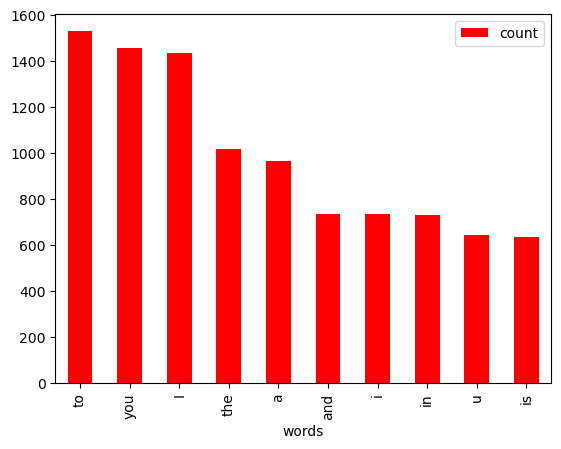

In [57]:
df1.plot.bar(color='red')
y_p = np.arange(len(df1["words in no-spam"]))
plt.xticks(y_p, df1["words in no-spam"])
plt.xlabel('words')
plt.show()

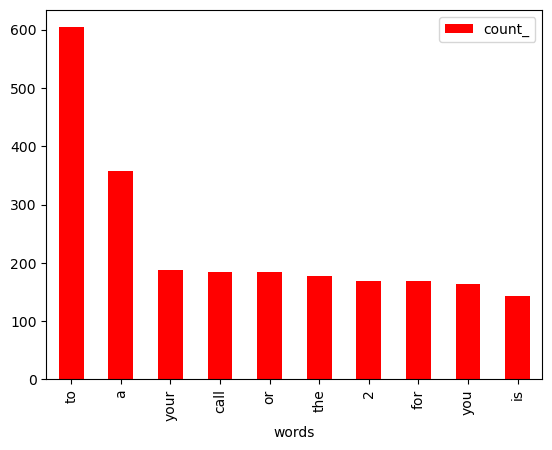

In [58]:
df2.plot.bar(color='red')
y_p = np.arange(len(df2['words in spam']))
plt.xticks(y_p, df2["words in spam"])
plt.xlabel('words')
plt.show()

<Axes: xlabel='v1', ylabel='count'>

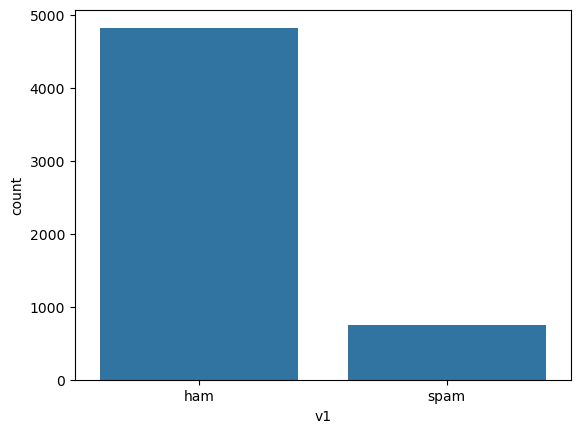

In [59]:
sns.countplot(data=data, x='v1')

In [60]:
#Feature Engineering
from sklearn import feature_extraction
f = feature_extraction.text.CountVectorizer(stop_words='english')
x = f.fit_transform(data['v2'])
np.shape(x)

(5572, 8404)

In [61]:
data['v1'].unique()

array(['ham', 'spam'], dtype=object)

In [62]:
data['v1']= data['v1'].map({'ham':0,'spam':1})

In [63]:
x_train, x_test, y_train, y_test = model_selection.train_test_split(x, data['v1'],test_size=0.2,random_state=42)

In [64]:
bayes = naive_bayes.MultinomialNB()

In [65]:
bayes.fit(x_train,y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [66]:
y_pred = bayes.predict(x_test)

In [67]:
accuracy_score(y_test,y_pred)

0.9802690582959641

In [68]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       965
           1       0.93      0.93      0.93       150

    accuracy                           0.98      1115
   macro avg       0.96      0.96      0.96      1115
weighted avg       0.98      0.98      0.98      1115



In [69]:
print(confusion_matrix(y_test,y_pred))

[[954  11]
 [ 11 139]]


In [70]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression


In [71]:
svc_l = SVC(kernel='linear')
svs_s = SVC(kernel='sigmoid')
svc_p = SVC(kernel='poly')
svc_r = SVC(kernel='rbf')

In [72]:
svc_l.fit(x_train,y_train)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [73]:
y_pred_svc = svc_l.predict(x_test)

In [74]:
print(classification_report(y_test,y_pred_svc))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       965
           1       0.99      0.86      0.92       150

    accuracy                           0.98      1115
   macro avg       0.99      0.93      0.96      1115
weighted avg       0.98      0.98      0.98      1115



In [75]:
knn = KNeighborsClassifier(n_neighbors=3)

In [76]:
knn.fit(x_train,y_train)

,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [77]:
y_pred_knn= knn.predict(x_test)

In [78]:
print(classification_report(y_test,y_pred_knn))

              precision    recall  f1-score   support

           0       0.92      1.00      0.96       965
           1       1.00      0.47      0.64       150

    accuracy                           0.93      1115
   macro avg       0.96      0.74      0.80      1115
weighted avg       0.93      0.93      0.92      1115



In [79]:
lor = LogisticRegression()

In [80]:
lor.fit(x_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [81]:
y_pred_lor = lor.predict(x_test)

In [82]:
print(classification_report(y_test,y_pred_lor))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       965
           1       1.00      0.84      0.91       150

    accuracy                           0.98      1115
   macro avg       0.99      0.92      0.95      1115
weighted avg       0.98      0.98      0.98      1115



In [83]:
accuracy_score(y_test,y_pred_lor)

0.97847533632287

In [92]:
knn = KNeighborsClassifier()

In [93]:
def Elbow(K):
    test_error = []
    for i in K:
        clf = KNeighborsClassifier(n_neighbors = i)
        clf.fit(x_train,y_train)
        tmp = clf.predict(x_test)
        tmp = f1_score(tmp,y_test)
        error = 1-tmp
        test_error.append(error)

    return test_error

In [94]:
k = range(1,20,2)

In [97]:
test = Elbow(k)

Text(0.5, 1.0, 'Elbow Curve Diagram')

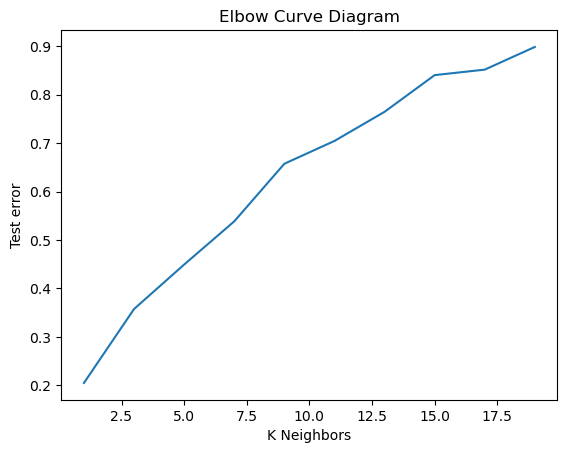

In [98]:
plt.plot(k,test)
plt.xlabel('K Neighbors')
plt.ylabel('Test error')
plt.title("Elbow Curve Diagram")